<a href="https://colab.research.google.com/github/SarveshMD/colab-notebooks/blob/main/pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
start = 0
end = 1
step = 0.01
X = torch.arange(start, end, step)

In [ ]:
weight = 0.6
bias = -0.3
y = weight * X + bias

In [ ]:
perm = torch.randperm(len(X))
X = X[perm]
y = y[perm]

In [ ]:
train_split = int(0.8*len(X))
X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

In [ ]:
def plot_dataset(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, predictions=None):
  plt.figure(figsize=(5,4))
  plt.scatter(X_train, y_train, s=4, c='r', label="Training Data")
  plt.scatter(X_test, y_test, s=4, c="g", label="Testing Data")
  if predictions is not None:
    plt.scatter(X_test, predictions, s=4, c="b", label="Predictions")

  plt.legend(prop={"size": 14})

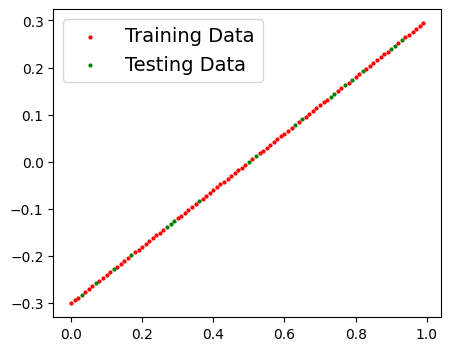

In [ ]:
plot_dataset()

In [ ]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, dtype=torch.float32), requires_grad=True)
    self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32)) # requires_grad = True is default behavior

  def forward(self, X):
    return self.weights * X + self.bias

In [26]:
torch.manual_seed(13)

model = LinearRegressionModel()

tensor([-1.2461, -1.1758, -1.1780, -1.2037, -1.2316, -1.2160, -1.2372, -1.2472,
        -1.1534, -1.2271, -1.2282, -1.1858, -1.2014, -1.2182, -1.1490, -1.1590,
        -1.2338, -1.1769, -1.2495, -1.1646])


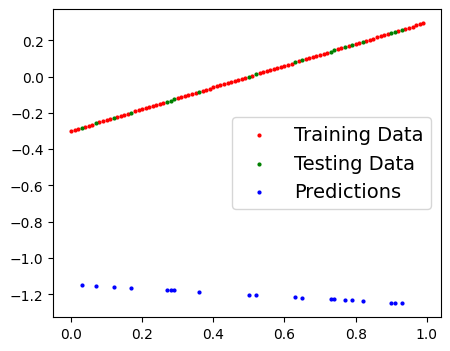

In [27]:
with torch.inference_mode():
  y_pred = model(X_test)
  print(y_pred)
plot_dataset(predictions=y_pred)

In [28]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [29]:
epochs = 400

epoch_count = []
train_loss_history = []
test_loss_history = []

for epoch in range(epochs):
  model.train()
  y_pred = model(X_train)
  loss = loss_fn(y_train, y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.inference_mode():
    y_test_pred = model(X_test)
    test_loss = loss_fn(y_test, y_test_pred)

  if epochs%10 == 0:
    epoch_count.append(epoch)
    train_loss_history.append(loss.detach().numpy())
    test_loss_history.append(test_loss.detach().numpy())
    # print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

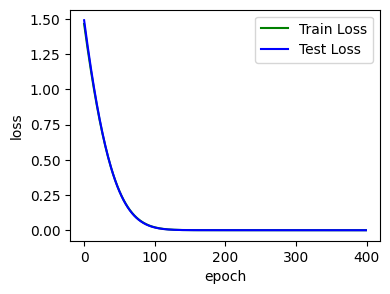

In [30]:
plt.figure(figsize=(4,3))
plt.plot(epoch_count, train_loss_history, c="g",label="Train Loss")
plt.plot(epoch_count, test_loss_history, c="b",label="Test Loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

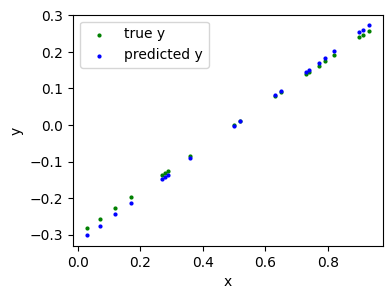

In [40]:
model.eval()
with torch.inference_mode():
  y_test_pred = model(X_test)

plt.figure(figsize=(4,3))
plt.scatter(X_test, y_test, c='g', s=4, label="true y")
plt.scatter(X_test, y_test_pred.detach().numpy(), c='b', s=4, label="predicted y")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [32]:
model.state_dict()

OrderedDict([('weights', tensor([0.6382])), ('bias', tensor([-0.3208]))])

In [33]:
from pathlib import Path

path = Path("models/workflow_model.pt")
path.parent.mkdir(parents=True, exist_ok=True)
path

PosixPath('models/workflow_model.pt')

In [34]:
torch.save(model.state_dict(), path)

In [35]:
loaded_model = LinearRegressionModel()

In [36]:
loaded_model.load_state_dict(torch.load(path))

<All keys matched successfully>

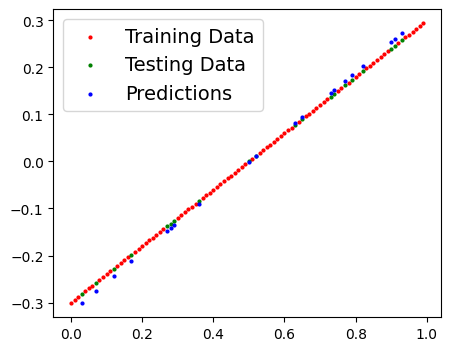

In [39]:
loaded_model.eval()
with torch.inference_mode():
  loaded_pred = loaded_model(X_test)
plot_dataset(predictions=loaded_pred.detach().numpy())

## Device complications when using matplotlib or numpy with tensors

```text
Need NumPy?
├─ Tensor on CPU?
│  ├─ requires_grad=False → .numpy()
│  └─ requires_grad=True  → .detach().numpy()
│
└─ Tensor on GPU?
   ├─ requires_grad=False → .cpu().numpy()
   └─ requires_grad=True  → .detach().cpu().numpy()
```